<a href="https://colab.research.google.com/github/Siraj0335/Final-Year-Project-Student-Psychological-Wellness-Siraj-Uddin-Mohammad-/blob/main/Code_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classification of Student Psychological Wellness Based on Substance Use and Lifestyle Habits**

# **1: Loading Relevent Libraries and dataset**

In this we read the dataset file and printed descriptive statistical Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('Student Smoking, Alcohol, and Mental Health Dataset_version-2.csv')

# Display basic info
print(df.info())
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1164 entries, 0 to 1163
Data columns (total 14 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   Timestamp                                                     1164 non-null   object
 1   Age                                                           1164 non-null   object
 2   Year of study                                                 1164 non-null   object
 3   Field of study                                                1164 non-null   object
 4   Frequency of smoking                                          1164 non-null   object
 5   Age of starting smoking                                       1164 non-null   object
 6   Reasons for smoking                                           1164 non-null   object
 7   Frequency of alcohol consumption                              1164 non-null   

# **2: Exploratory Data Analysis**

## **Demographic Analysis**

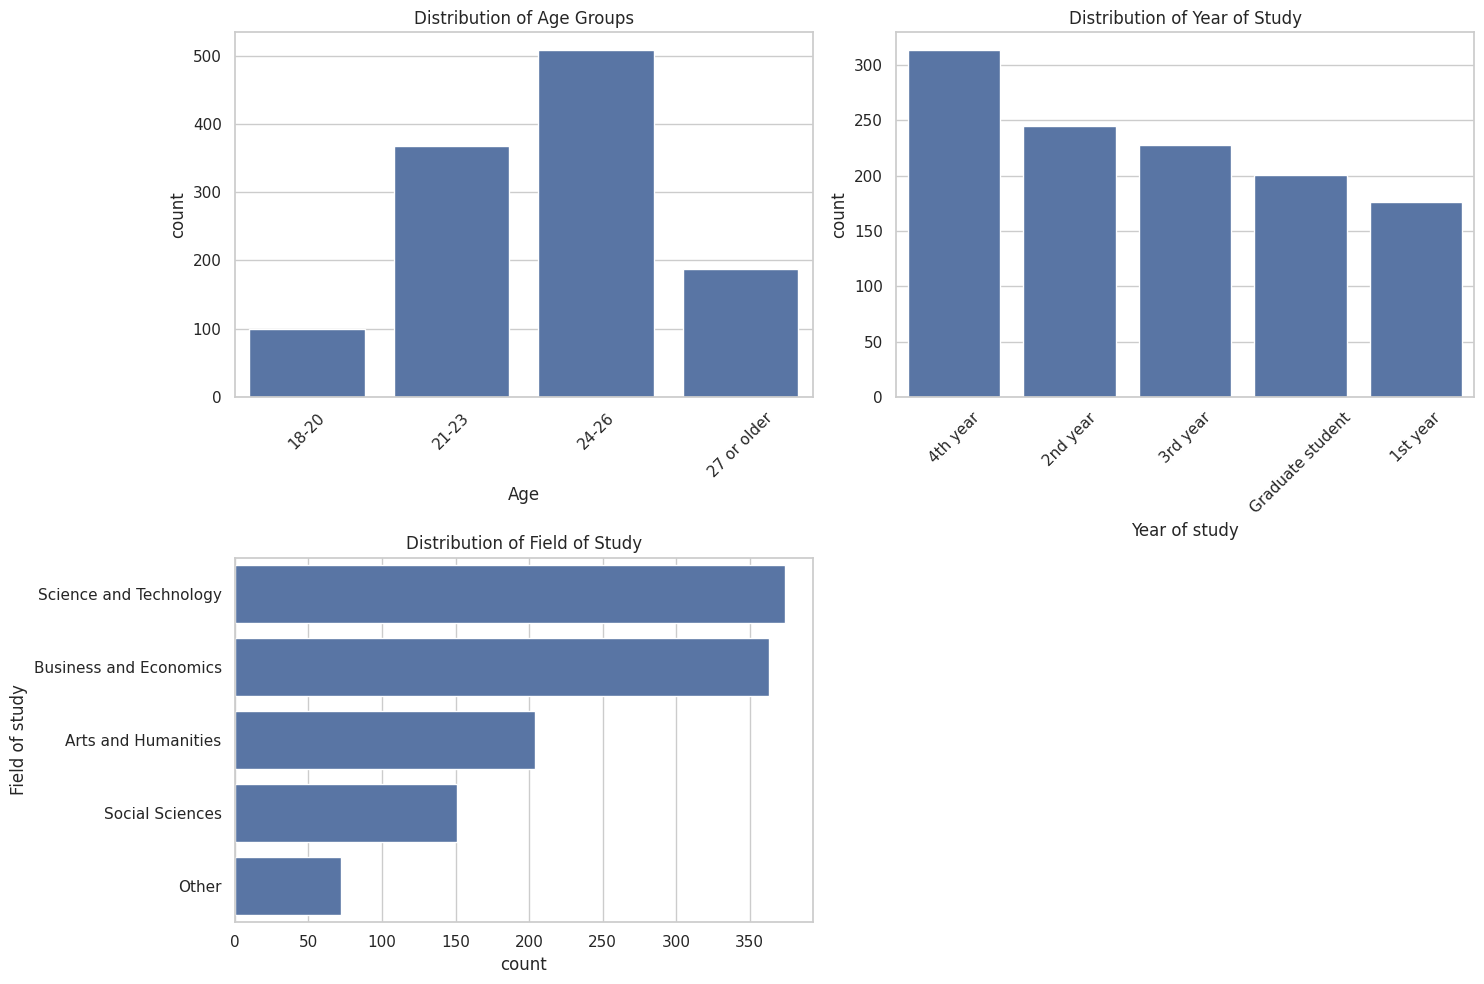

In [3]:
plt.figure(figsize=(15, 10))

# Age Distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Age', order=sorted(df['Age'].unique()))
plt.title('Distribution of Age Groups')
plt.xticks(rotation=45)

# Year of Study
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Year of study', order=df['Year of study'].value_counts().index)
plt.title('Distribution of Year of Study')
plt.xticks(rotation=45)

# Field of Study
plt.subplot(2, 2, 3)
sns.countplot(data=df, y='Field of study', order=df['Field of study'].value_counts().index)
plt.title('Distribution of Field of Study')

plt.tight_layout()
plt.show()

## **Substance Use Patterns**
Here we analyze the frequency and primary reasons for smoking and alcohol consumption among students.

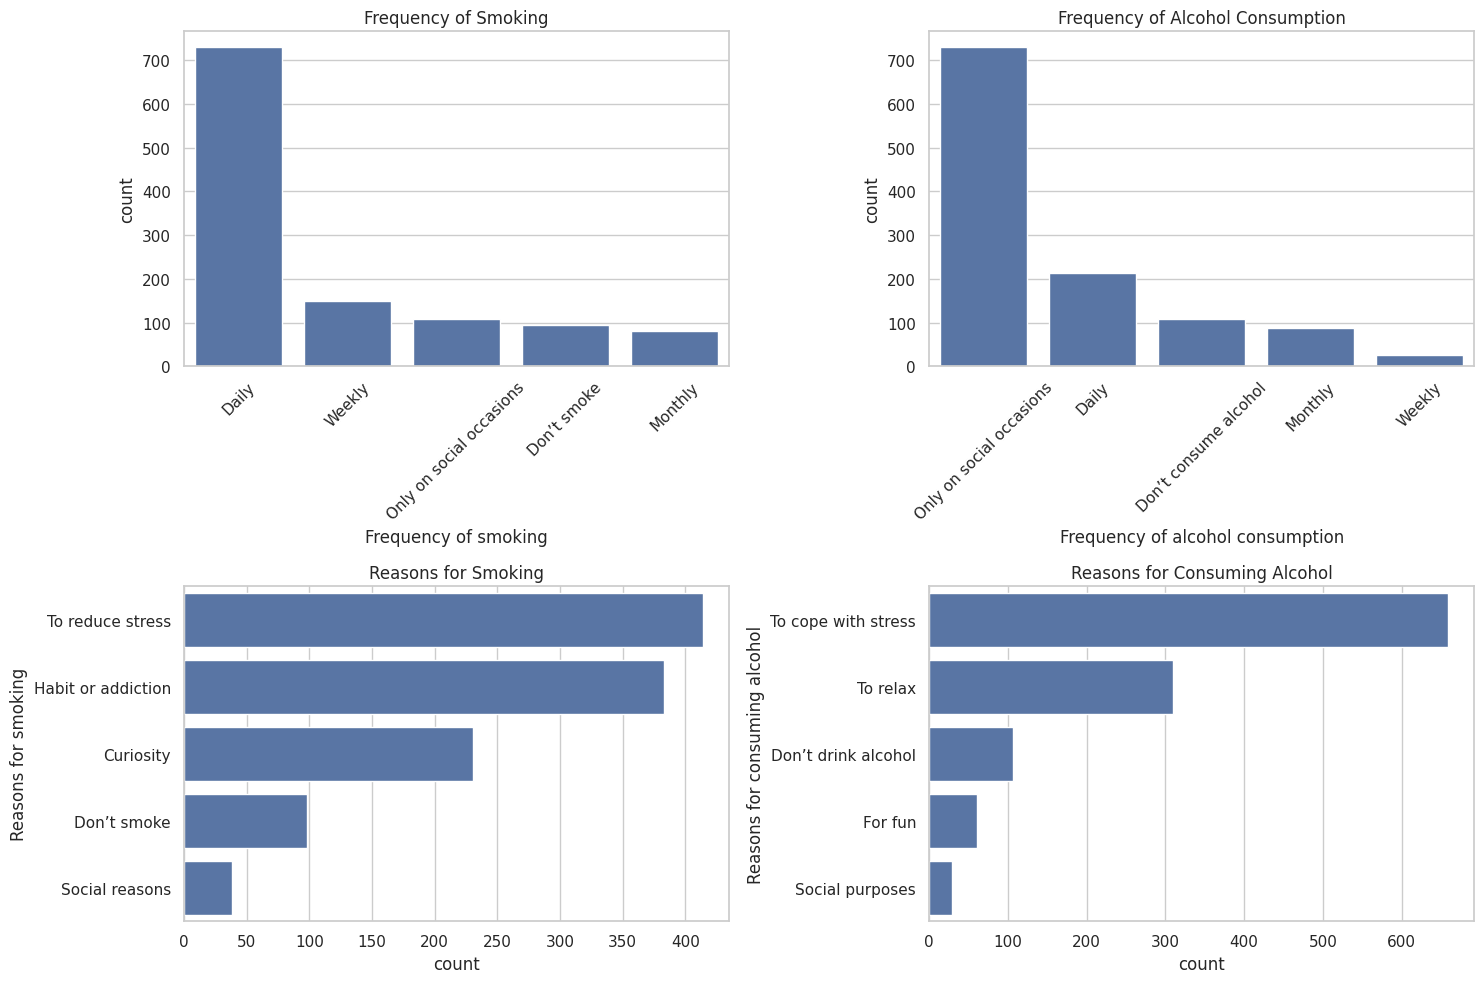

In [4]:
plt.figure(figsize=(15, 10))

# Smoking Frequency
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Frequency of smoking', order=df['Frequency of smoking'].value_counts().index)
plt.title('Frequency of Smoking')
plt.xticks(rotation=45)

# Alcohol Frequency
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Frequency of alcohol consumption', order=df['Frequency of alcohol consumption'].value_counts().index)
plt.title('Frequency of Alcohol Consumption')
plt.xticks(rotation=45)

# Reasons for Smoking
plt.subplot(2, 2, 3)
sns.countplot(data=df, y='Reasons for smoking', order=df['Reasons for smoking'].value_counts().index)
plt.title('Reasons for Smoking')

# Reasons for Alcohol
plt.subplot(2, 2, 4)
sns.countplot(data=df, y='Reasons for consuming alcohol', order=df['Reasons for consuming alcohol'].value_counts().index)
plt.title('Reasons for Consuming Alcohol')

plt.tight_layout()
plt.show()

## **Psychological Wellness and Help-Seeking**
This block focuses on the mental health status of the students and whether they are open to seeking help.

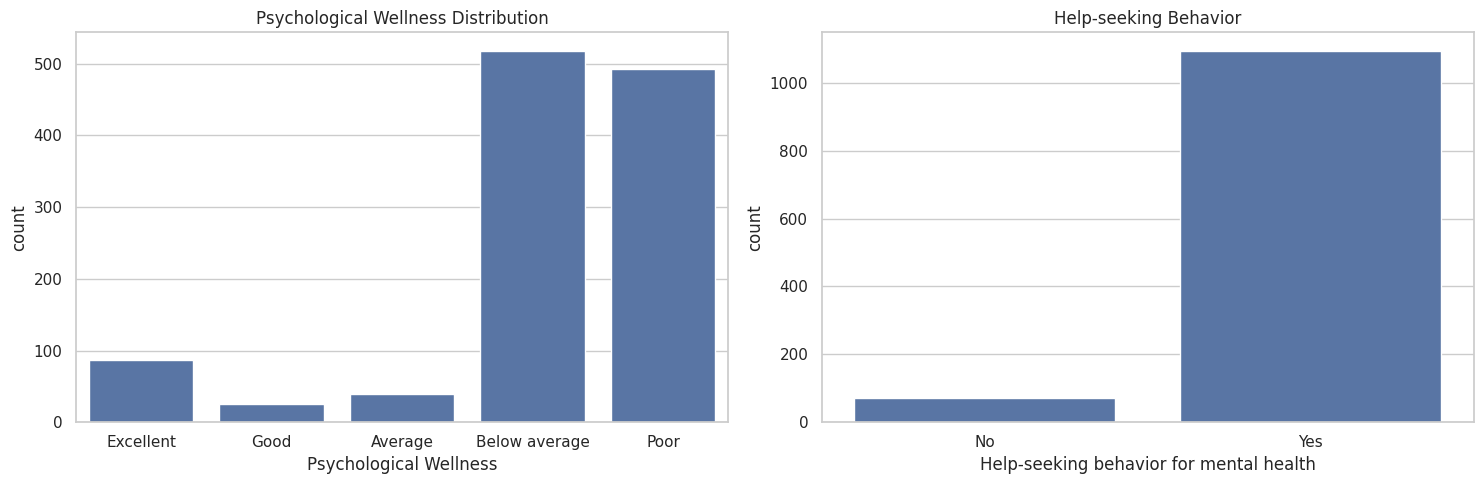

In [5]:
plt.figure(figsize=(15, 5))

# Wellness Distribution
plt.subplot(1, 2, 1)
wellness_order = ['Excellent', 'Good', 'Average', 'Below average', 'Poor']
sns.countplot(data=df, x='Psychological Wellness',
              order=[w for w in wellness_order if w in df['Psychological Wellness'].unique()])
plt.title('Psychological Wellness Distribution')

# Help-seeking Behavior
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Help-seeking behavior for mental health')
plt.title('Help-seeking Behavior')

plt.tight_layout()
plt.show()

## **Correlation: Substance Use vs. Mental Health**
We use heatmaps to see how smoking and alcohol frequency relate to psychological wellness levels.

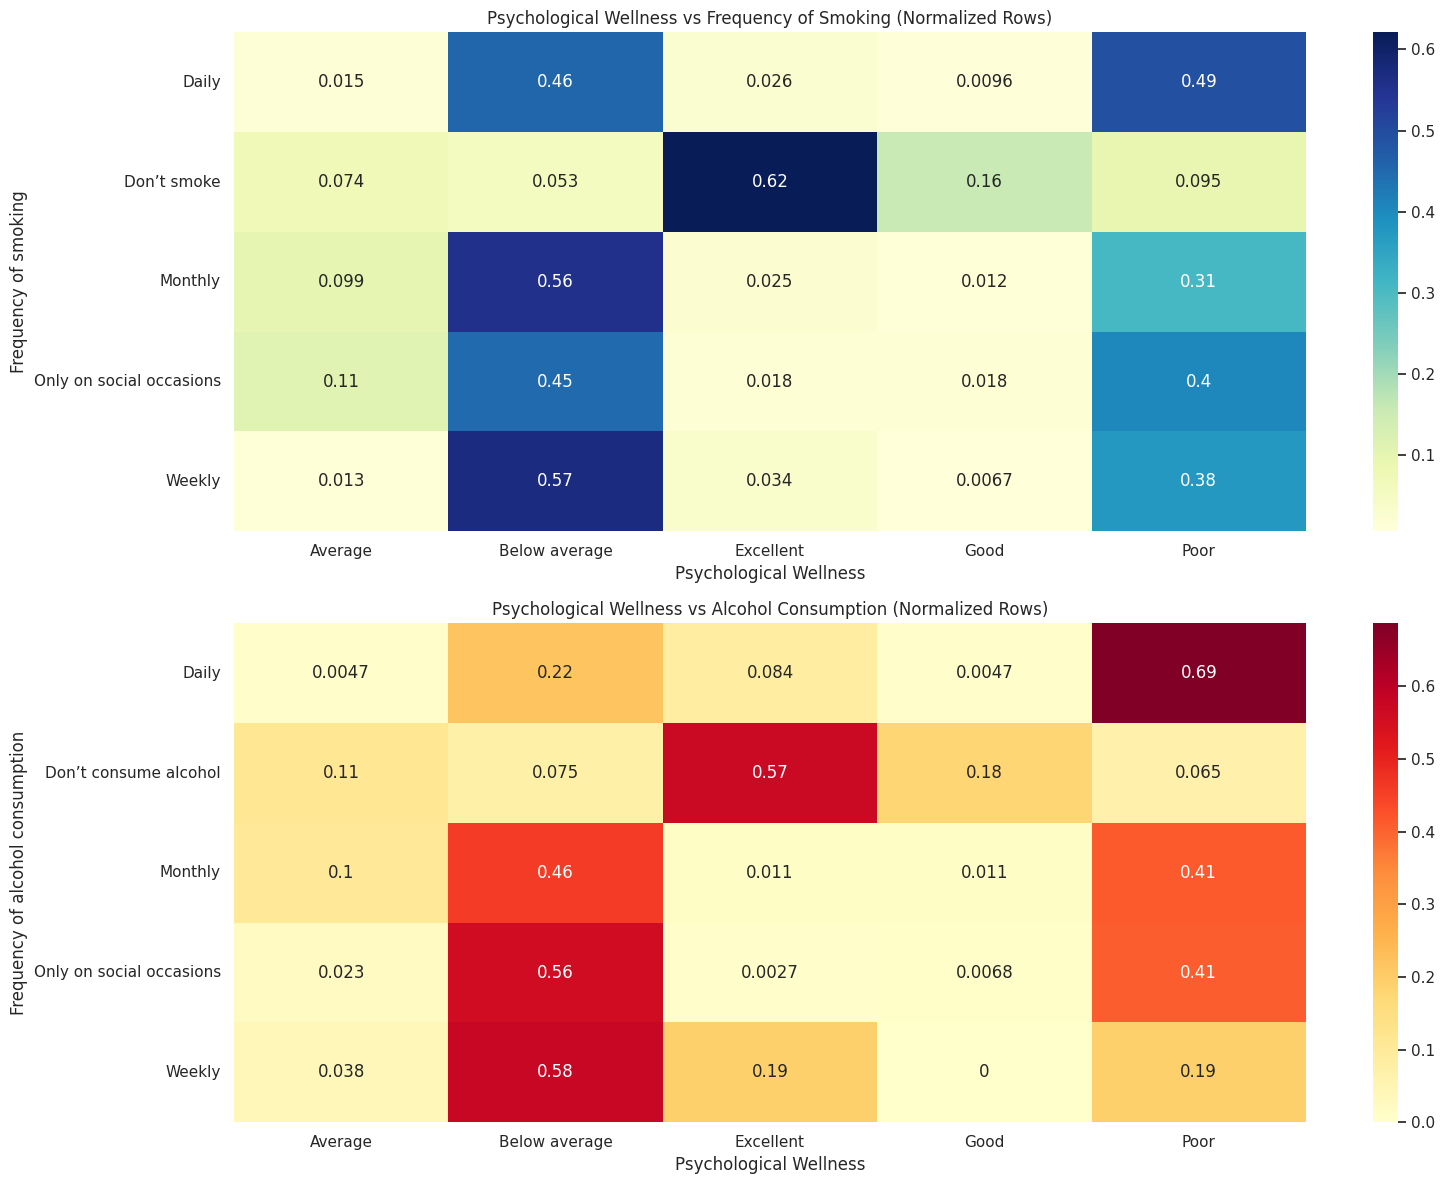

In [6]:
plt.figure(figsize=(16, 12))

# Smoking vs Wellness Heatmap (Normalized)
plt.subplot(2, 1, 1)
ct_smoke = pd.crosstab(df['Frequency of smoking'], df['Psychological Wellness'], normalize='index')
sns.heatmap(ct_smoke, annot=True, cmap='YlGnBu')
plt.title('Psychological Wellness vs Frequency of Smoking (Normalized Rows)')

# Alcohol vs Wellness Heatmap (Normalized)
plt.subplot(2, 1, 2)
ct_alcohol = pd.crosstab(df['Frequency of alcohol consumption'], df['Psychological Wellness'], normalize='index')
sns.heatmap(ct_alcohol, annot=True, cmap='YlOrRd')
plt.title('Psychological Wellness vs Alcohol Consumption (Normalized Rows)')

plt.tight_layout()
plt.show()

## **Correlational HeatMap**

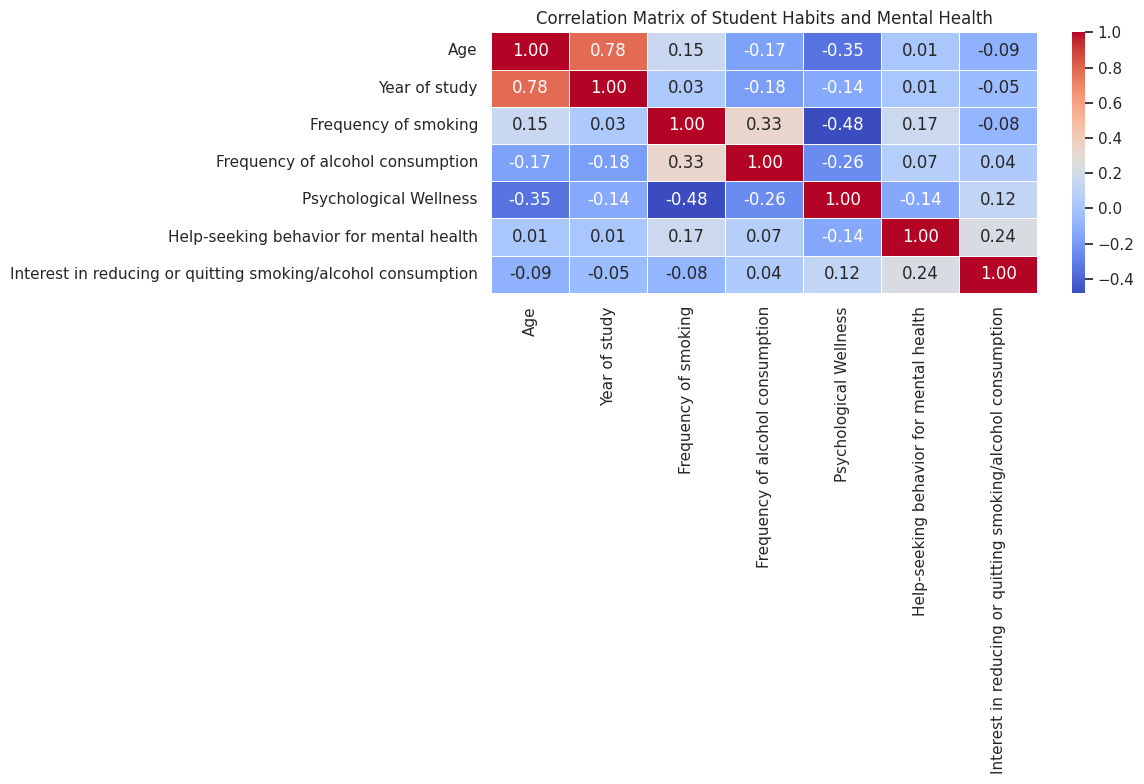

                                                         Age  Year of study  \
Age                                                 1.000000       0.781121   
Year of study                                       0.781121       1.000000   
Frequency of smoking                                0.151703       0.030482   
Frequency of alcohol consumption                   -0.173642      -0.182319   
Psychological Wellness                             -0.346220      -0.137624   
Help-seeking behavior for mental health             0.013991       0.005865   
Interest in reducing or quitting smoking/alcoho... -0.094020      -0.047040   

                                                    Frequency of smoking  \
Age                                                             0.151703   
Year of study                                                   0.030482   
Frequency of smoking                                            1.000000   
Frequency of alcohol consumption                               

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define ordinal mappings for categorical columns
mappings = {
    'Age': {'18-20': 0, '21-23': 1, '24-26': 2, '27 or older': 3},
    'Year of study': {'1st year': 1, '2nd year': 2, '3rd year': 3, '4th year': 4, 'Graduate student': 5},
    'Frequency of smoking': {'Don’t smoke': 0, 'Only on social occasions': 1, 'Monthly': 2, 'Weekly': 3, 'Daily': 4},
    'Frequency of alcohol consumption': {'Don’t consume alcohol': 0, 'Only on social occasions': 1, 'Monthly': 2, 'Weekly': 3, 'Daily': 4},
    'Psychological Wellness': {'Poor': 0, 'Below average': 1, 'Average': 2, 'Good': 3, 'Excellent': 4},
    'Help-seeking behavior for mental health': {'No': 0, 'Yes': 1},
    'Interest in reducing or quitting smoking/alcohol consumption': {'No': 0, 'Yes': 1}
}

# 2. Create a copy and map values to numeric
df_numeric = df.copy()
for col, mapping in mappings.items():
    df_numeric[col] = df_numeric[col].map(mapping)

# 3. Calculate Correlation Matrix
corr_matrix = df_numeric[list(mappings.keys())].corr()

# 4. Visualize the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Student Habits and Mental Health')
plt.tight_layout()
plt.show()

# Display the raw correlation table
print(corr_matrix)

## **Target Variable Distribution**

/tmp/ipython-input-2730007391.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Psychological Wellness', order=wellness_order, palette='viridis')


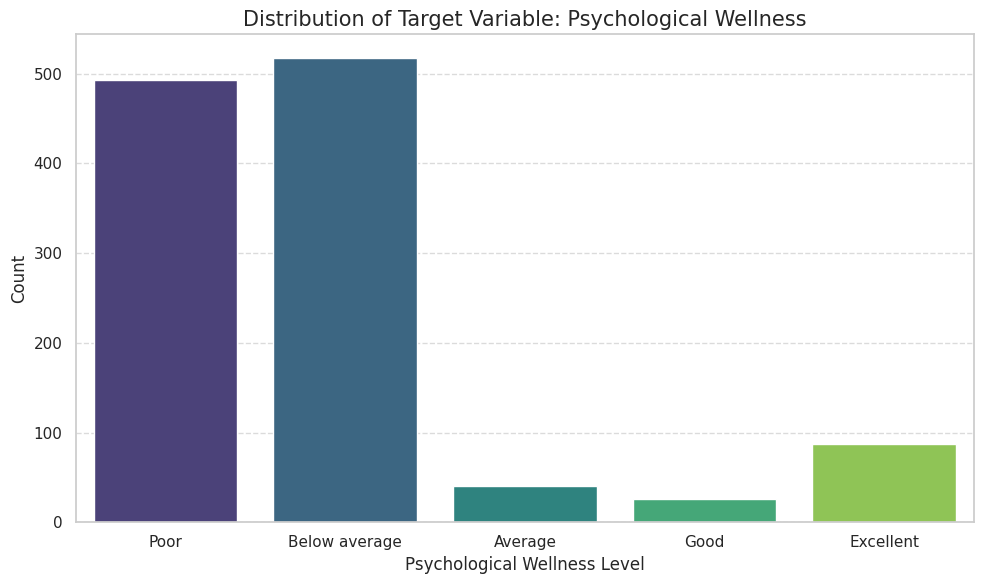

Psychological Wellness
Poor             493
Below average    518
Average           40
Good              26
Excellent         87
Name: count, dtype: int64


In [8]:
# Define the logical order for the wellness categories (from lowest to highest)
wellness_order = ['Poor', 'Below average', 'Average', 'Good', 'Excellent']

# Plot the distribution of the target variable 'Psychological Wellness'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Psychological Wellness', order=wellness_order, palette='viridis')

plt.title('Distribution of Target Variable: Psychological Wellness', fontsize=15)
plt.xlabel('Psychological Wellness Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Display value counts for numerical reference
print(df['Psychological Wellness'].value_counts().reindex(wellness_order))